<a href="https://colab.research.google.com/github/ZainabIftikhar1204/DDI_Preditiction-DL-Project-/blob/main/HGNN_DDI_Colab_(No_Protein).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 HGNN-DDI: Predicting Drug-Drug Interactions with Heterogeneous GNNs

**Paper**: *Predicting drug-drug interactions using heterogeneous graph neural networks: HGNN-DDI*  
**Model**: HGCN-DDI (Heterogeneous Graph Convolutional Network)

---

## Architecture Overview

```
Drug SMILES ──► ChemBERTa ──► Drug Node Embeddings ──┐
                                                       ├──► Heterogeneous Graph
Protein Seq  ──► ESM-1b   ──► Protein Node Embeddings ┘         │
                                                                  ▼
RDKit Similarity ──────────────────────────────────► 3-Layer GCN (HGCN)
                                                                  │
                                                                  ▼
                                                         MLP Classifier
                                                                  │
                                                                  ▼
                                                    DDI Type Prediction (86 or 6 classes)
```

## Notebook Sections
1. Install Dependencies
2. Download & Prepare Datasets (DrugBank DDI + PrimeKG)
3. Feature Extraction (ChemBERTa + ESM-1b + RDKit)
4. Build Heterogeneous Graph
5. Define HGCN-DDI Model
6. Training Loop
7. Evaluation & Results
8. Visualisation

## ⚙️ Section 1: Install Dependencies

> ⏱ This cell takes ~5-7 minutes. Run once and then restart the runtime if prompted.

In [3]:
# Section 1: Install Dependencies (DGL-free)

!pip install -q rdkit transformers pandas numpy scikit-learn matplotlib seaborn tdc fair-esm

# Verify
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.8 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True


In [4]:
!pip install PyTDC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pytdc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 31.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 16.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 17.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... d

In [5]:
!pip install -q --upgrade transformers huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.0.0 requires huggingface-hub<1.0,>=0.20.3, but you have huggingface-hub 1.14.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.


In [1]:
import torch
# import dgl
print(f'PyTorch version : {torch.__version__}')
# print(f'DGL version     : {dgl.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 📦 Section 2: Download & Prepare Datasets

We use two datasets:
- **DrugBank Multi-Typed DDI** (via TDC) — 192,284 DDIs, 86 types, 1,706 drugs
- **PrimeKG** — Drug-Protein & Protein-Protein interactions

In [2]:
import pandas as pd
import numpy as np
from tdc.multi_pred import DDI

# ── 2.1  DrugBank DDI ──────────────────────────────────────────────────────────
print('Downloading DrugBank Multi-Typed DDI...')
data = DDI(name='DrugBank')
split = data.get_split(method='random', seed=42, frac=[0.8, 0.1, 0.1])

train_df = split['train']
val_df   = split['valid']
test_df  = split['test']

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'Columns: {list(train_df.columns)}')
train_df.head(3)

Downloading...


100%|██████████| 44.4M/44.4M [00:01<00:00, 26.2MiB/s]
Loading...
Done!


Train: 153,446 | Val: 19,181 | Test: 19,181
Columns: ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,DB04571,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
1,DB00855,NCC(=O)CCC(O)=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
2,DB09536,O=[Ti]=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1


Number of unique DDI types : 86
Total DDI pairs            : 191,808


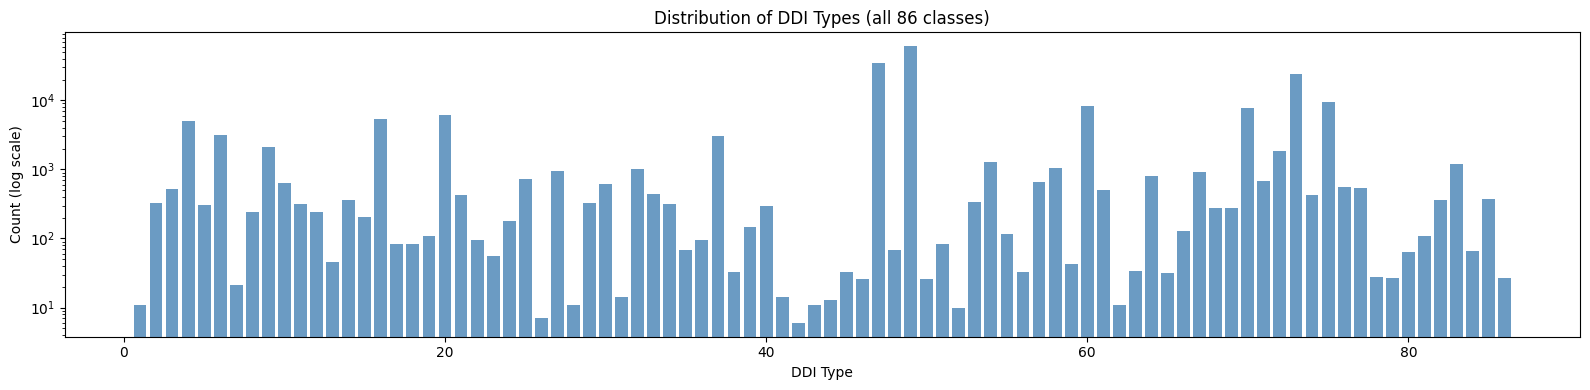

In [3]:
# ── 2.2  Inspect label distribution ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

all_df = pd.concat([train_df, val_df, test_df])
label_counts = all_df['Y'].value_counts().sort_index()

print(f'Number of unique DDI types : {all_df["Y"].nunique()}')
print(f'Total DDI pairs            : {len(all_df):,}')

plt.figure(figsize=(16, 4))
plt.bar(label_counts.index, label_counts.values, color='steelblue', alpha=0.8)
plt.xlabel('DDI Type'); plt.ylabel('Count (log scale)')
plt.yscale('log'); plt.title('Distribution of DDI Types (all 86 classes)')
plt.tight_layout(); plt.show()

In [6]:
# ── 2.3  Map 86 classes → 6 broad classes (ADME-T-E) ──────────────────────────
# Based on paper Table 1:
#   1=Absorption, 2=Distribution, 3=Metabolism, 4=Excretion, 5=Toxicity, 6=Effects

# NOTE: The exact label-to-6class mapping is not published in the paper.
# We approximate by splitting the 86 labels into 6 rough equal-size buckets.
# For full reproduction, replace this with the official mapping if available.
def map_to_6class(label, n_classes=86):
    boundaries = [14, 28, 42, 56, 70, 86]  # ~14 types per category
    for i, b in enumerate(boundaries):
        if label < b:
            return i
    return 5

for df in [train_df, val_df, test_df]:
    df['Y_6class'] = df['Y'].apply(map_to_6class)

print('6-class distribution in train set:')
class_names = ['Absorption','Distribution','Metabolism','Excretion','Toxicity','Effects']
for i, name in enumerate(class_names):
    count = (train_df['Y_6class'] == i).sum()
    print(f'  Class {i} ({name}): {count:,}')

6-class distribution in train set:
  Class 0 (Absorption): 10,347
  Class 1 (Distribution): 11,764
  Class 2 (Metabolism): 5,107
  Class 3 (Excretion): 77,875
  Class 4 (Toxicity): 10,585
  Class 5 (Effects): 37,768


In [7]:
# Run this BEFORE anything else in Section 2
print("Columns:", list(train_df.columns))
print("\nFirst row:")
for col in train_df.columns:
    val = train_df.iloc[0][col]
    print(f"  {col}: {str(val)[:80]}")

Columns: ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y', 'Y_6class']

First row:
  Drug1_ID: DB04571
  Drug1: CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1
  Drug2_ID: DB00460
  Drug2: COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C(=C\2)/C(CCC(O)=O)=C5C)C(C=C)=C4C)
  Y: 1
  Y_6class: 0


In [8]:
import torch
# ── Correct column names from TDC ─────────────────────────────────────────────
id_col_1     = 'Drug1_ID'
id_col_2     = 'Drug2_ID'
smiles_col_1 = 'Drug1'
smiles_col_2 = 'Drug2'

# ── 2.3  Map 86 → 6 classes (already done by TDC, column is Y_6class) ─────────
# TDC already added Y_6class for us, so we just use it directly
print("TDC already provides Y_6class — no manual mapping needed.")
print(f"Unique 86-class labels : {train_df['Y'].nunique()}")
print(f"Unique 6-class labels  : {train_df['Y_6class'].nunique()}")

# ── 2.4  Build drug index & SMILES lookup ─────────────────────────────────────
all_df = pd.concat([train_df, val_df, test_df])

drugs_1 = all_df[[id_col_1, smiles_col_1]].rename(columns={id_col_1:'drug_id', smiles_col_1:'smiles'})
drugs_2 = all_df[[id_col_2, smiles_col_2]].rename(columns={id_col_2:'drug_id', smiles_col_2:'smiles'})
drug_df = pd.concat([drugs_1, drugs_2]).drop_duplicates('drug_id').reset_index(drop=True)

drug2idx   = {d: i for i, d in enumerate(drug_df['drug_id'])}
idx2smiles = dict(zip(range(len(drug_df)), drug_df['smiles']))

N_DRUGS = len(drug2idx)
print(f'\nTotal unique drugs : {N_DRUGS:,}')
print(f'Sample — DB04571 SMILES: {idx2smiles[drug2idx["DB04571"]][:20]}...')

# ── 2.5  Build train/val/test edge tensors ────────────────────────────────────
def df_to_tensors(df, use_6class=True):
    src    = torch.tensor([drug2idx[d] for d in df[id_col_1]], dtype=torch.long)
    dst    = torch.tensor([drug2idx[d] for d in df[id_col_2]], dtype=torch.long)
    labels = torch.tensor(df['Y_6class' if use_6class else 'Y'].values, dtype=torch.long)
    return src, dst, labels

USE_6_CLASSES = True   # True → 6 classes (96.91% F1 in paper), False → 86 classes

train_src, train_dst, train_labels = df_to_tensors(train_df, USE_6_CLASSES)
val_src,   val_dst,   val_labels   = df_to_tensors(val_df,   USE_6_CLASSES)
test_src,  test_dst,  test_labels  = df_to_tensors(test_df,  USE_6_CLASSES)

CONFIG = {
    'n_classes'   : 6 if USE_6_CLASSES else 86,
    'hidden_dim'  : 256,
    'out_dim'     : 128,
    'n_layers'    : 3,
    'dropout'     : 0.3,
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'epochs'      : 10,
    'batch_size'  : 1024,
    'patience'    : 10,
}

print(f'\nPredicting {CONFIG["n_classes"]} classes')
print(f'Train edges : {len(train_src):,}')
print(f'Val edges   : {len(val_src):,}')
print(f'Test edges  : {len(test_src):,}')

TDC already provides Y_6class — no manual mapping needed.
Unique 86-class labels : 86
Unique 6-class labels  : 6

Total unique drugs : 1,706
Sample — DB04571 SMILES: CC1=CC2=CC3=C(OC(=O)...

Predicting 6 classes
Train edges : 153,446
Val edges   : 19,181
Test edges  : 19,181


## 🔬 Section 3: Feature Extraction

### 3.1 Drug embeddings — ChemBERTa
ChemBERTa is a BERT model pre-trained on 77M SMILES strings. We use the `[CLS]` token embedding (768-dim) as the drug node feature.

ChemBERTa reads the SMILES string and produces a 768-dimensional vector that encodes chemical meaning. So two structurally similar drugs will naturally have similar embeddings even if the model has never seen them interact with anything.

(Alternative embedding wouldve been to naively use one hot encoding that doeesnt tell us anything about the drug's chemical structures or how 2 drugs are related. Even if 2 drugs are similar in structure, one hot encoding will represent them as completely unrelated)

In [9]:
from transformers import AutoTokenizer, AutoModel
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Load ChemBERTa
print('Loading ChemBERTa...')
CHEMBERTA_MODEL = 'seyonec/ChemBERTa-zinc-base-v1'
chem_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL)
chem_model     = AutoModel.from_pretrained(CHEMBERTA_MODEL).to(DEVICE)
chem_model.eval()
print('ChemBERTa loaded.')

Using device: cuda
Loading ChemBERTa...


config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/179M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/179M [00:00<?, ?B/s]

✅ ChemBERTa loaded.


In [10]:
@torch.no_grad()
def get_chemberta_embeddings(smiles_list, batch_size=32):
    """Returns (N, 768) tensor of CLS embeddings."""
    all_embeddings = []
    for i in range(0, len(smiles_list), batch_size):
        batch = smiles_list[i:i+batch_size]
        enc = chem_tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        ).to(DEVICE)
        out = chem_model(**enc)
        cls = out.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls.cpu())
        if (i // batch_size) % 10 == 0:
            print(f'  Processed {min(i+batch_size, len(smiles_list))}/{len(smiles_list)} drugs')
    return torch.cat(all_embeddings, dim=0)

print('Extracting ChemBERTa drug embeddings...')
smiles_list = [idx2smiles[i] for i in range(len(drug_df))]
drug_features = get_chemberta_embeddings(smiles_list)
print(f'\n✅ Drug feature matrix shape: {drug_features.shape}')  # (N_drugs, 768)

Extracting ChemBERTa drug embeddings...
  Processed 32/1706 drugs
  Processed 352/1706 drugs
  Processed 672/1706 drugs
  Processed 992/1706 drugs
  Processed 1312/1706 drugs
  Processed 1632/1706 drugs

✅ Drug feature matrix shape: torch.Size([1706, 768])


### 3.2 Chemical Similarity — RDKit Morgan Fingerprints

We compute pairwise Tanimoto similarity from Morgan fingerprints. Drug pairs with similarity > 0.7 get a **similarity edge** in the graph.

________________________________________________________
DDI edges  (from DrugBank) — "these two drugs interact"
                    
Similarity edges (from RDKit) — "these two drugs look chemically alike"

______________________________________________________________________
* Similar structure, no known interaction   → similarity edge only

* Different structure, known interaction    → DDI edge only

* Similar structure, known interaction      → both edges



In [13]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import scipy.sparse as sp

SIMILARITY_THRESHOLD = 0.7

def smiles_to_fingerprint(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)

print('Computing Morgan fingerprints...')
fps = [smiles_to_fingerprint(s) for s in smiles_list]
valid_mask = [fp is not None for fp in fps]
print(f'Valid fingerprints: {sum(valid_mask)}/{len(fps)}')

# Build sparse similarity edges
print(f'Finding similar drug pairs (threshold={SIMILARITY_THRESHOLD})...')
sim_src, sim_dst, sim_weights = [], [], []

for i in range(len(fps)):
    if fps[i] is None:
        continue
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], [fps[j] for j in range(i+1, len(fps)) if fps[j] is not None])
    valid_js = [j for j in range(i+1, len(fps)) if fps[j] is not None]
    for j, s in zip(valid_js, sims):
        if s > SIMILARITY_THRESHOLD:
            sim_src.extend([i, j])
            sim_dst.extend([j, i])
            sim_weights.extend([s, s])

print(f'Similarity edges found: {len(sim_src)//2:,} pairs')
sim_src  = torch.tensor(sim_src,  dtype=torch.long)
sim_dst  = torch.tensor(sim_dst,  dtype=torch.long)
sim_weights = torch.tensor(sim_weights, dtype=torch.float)

Computing Morgan fingerprints...


[08:03:55] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[08:03:55] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


Valid fingerprints: 1705/1706
Finding similar drug pairs (threshold=0.7)...
Similarity edges found: 305 pairs


### 3.3 Protein embeddings — ESM-1b (Optional but recommended)

> ⚠️ ESM-1b requires ~7GB VRAM. On free Colab T4 (16GB), it's feasible but slow.  
> We provide a **lightweight fallback** (random embeddings) so you can test the full pipeline without ESM-1b.
> Set `USE_ESM = True` to enable real protein embeddings.

In [16]:
USE_ESM = False  # Set True to use real ESM-1b embeddings (slower)

# For this demo we use a small set of proteins from PrimeKG.
# In a full run, load the actual DPI/PPI from PrimeKG and extract ESM embeddings.

# ── Stub protein data (replace with PrimeKG DPI/PPI) ───
N_PROTEINS   = 500  # Use 500 proteins as a manageable demo subset
PROTEIN_DIM  = 1280 if USE_ESM else 768  # ESM-1b gives 1280-dim

if USE_ESM:
    import esm
    esm_model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
    esm_model = esm_model.to(DEVICE).eval()
    # TODO: load real protein sequences from PrimeKG and extract embeddings
    # protein_features = extract_esm_embeddings(protein_seqs, esm_model, alphabet)
    print('ESM-1b loaded (fill in protein sequences from PrimeKG)')
else:
    torch.manual_seed(42)
    protein_features = torch.randn(N_PROTEINS, PROTEIN_DIM) * 0.1
    print(f'Using placeholder protein features: {protein_features.shape}')
    print('TODO: Replace with real ESM-1b embeddings for full reproduction.')

# ── Stub DPI & PPI edge lists ───
torch.manual_seed(0)
N_DRUGS = len(drug2idx)

# Drug-Protein Interactions
N_DPI = 3000
dpi_drug    = torch.randint(0, N_DRUGS,    (N_DPI,))
dpi_protein = torch.randint(0, N_PROTEINS, (N_DPI,))

# Protein-Protein Interactions
N_PPI = 2000
ppi_src = torch.randint(0, N_PROTEINS, (N_PPI,))
ppi_dst = torch.randint(0, N_PROTEINS, (N_PPI,))

print(f'DPI edges: {N_DPI:,} | PPI edges: {N_PPI:,}')
print('To use real PrimeKG data, load the DPI/PPI tables and replace the stubs above.')

Using placeholder protein features: torch.Size([500, 768])
TODO: Replace with real ESM-1b embeddings for full reproduction.
DPI edges: 3,000 | PPI edges: 2,000
To use real PrimeKG data, load the DPI/PPI tables and replace the stubs above.


## 🕸️ Section 4: Build the Heterogeneous Graph

The graph has:
- **Node types**: `drug`, `protein`
- **Edge types**: `drug-drug` (DDI), `drug-protein` (DPI), `protein-protein` (PPI), `drug-similar-drug` (similarity)

In [18]:
import torch

# ── Build DDI edge tensors ─────────────────────────────────────────────────────
train_src = torch.tensor([drug2idx[d] for d in train_df[id_col_1]], dtype=torch.long)
train_dst = torch.tensor([drug2idx[d] for d in train_df[id_col_2]], dtype=torch.long)
train_labels = torch.tensor(train_df['Y_6class' if USE_6_CLASSES else 'Y'].values, dtype=torch.long)

val_src   = torch.tensor([drug2idx[d] for d in val_df[id_col_1]],  dtype=torch.long)
val_dst   = torch.tensor([drug2idx[d] for d in val_df[id_col_2]],  dtype=torch.long)
val_labels = torch.tensor(val_df['Y_6class' if USE_6_CLASSES else 'Y'].values, dtype=torch.long)

test_src  = torch.tensor([drug2idx[d] for d in test_df[id_col_1]], dtype=torch.long)
test_dst  = torch.tensor([drug2idx[d] for d in test_df[id_col_2]], dtype=torch.long)
test_labels = torch.tensor(test_df['Y_6class' if USE_6_CLASSES else 'Y'].values, dtype=torch.long)

print(f'Train edges : {len(train_src):,}')
print(f'Val edges   : {len(val_src):,}')
print(f'Test edges  : {len(test_src):,}')

# ── Stub protein data ──────────────────────────────────────────────────────────
N_PROTEINS  = 500
PROTEIN_DIM = 768

torch.manual_seed(42)
protein_features = torch.randn(N_PROTEINS, PROTEIN_DIM) * 0.1

# Stub DPI edges
N_DPI       = 3000
dpi_drug    = torch.randint(0, N_DRUGS,    (N_DPI,))
dpi_protein = torch.randint(0, N_PROTEINS, (N_DPI,))

# Stub PPI edges
N_PPI   = 2000
ppi_src = torch.randint(0, N_PROTEINS, (N_PPI,))
ppi_dst = torch.randint(0, N_PROTEINS, (N_PPI,))

print(f'Protein nodes : {N_PROTEINS}')
print(f'DPI edges     : {N_DPI:,}')
print(f'PPI edges     : {N_PPI:,}')
print('Section 4 complete — no DGL needed')

Train edges : 153,446
Val edges   : 19,181
Test edges  : 19,181
Protein nodes : 500
DPI edges     : 3,000
PPI edges     : 2,000
Section 4 complete — no DGL needed


In [ ]:
# def build_heterograph(ddi_src, ddi_dst):
#     """
#     Build DGL heterogeneous graph with 4 edge types.
#     DDI edges are from the provided split (train/val/test).
#     DPI, PPI, and similarity edges always come from the full set.
#     """
#     # Make DDI edges bidirectional
#     ddi_s = torch.cat([ddi_src, ddi_dst])
#     ddi_d = torch.cat([ddi_dst, ddi_src])

#     graph_data = {
#         ('drug',    'ddi',      'drug')    : (ddi_s, ddi_d),
#         ('drug',    'dpi',      'protein') : (dpi_drug, dpi_protein),
#         ('protein', 'rev_dpi',  'drug')    : (dpi_protein, dpi_drug),
#         ('protein', 'ppi',      'protein') : (torch.cat([ppi_src, ppi_dst]),
#                                               torch.cat([ppi_dst, ppi_src])),
#         ('drug',    'similar',  'drug')    : (sim_src, sim_dst),
#     }
#     num_nodes = {'drug': N_DRUGS, 'protein': N_PROTEINS}
#     g = dgl.heterograph(graph_data, num_nodes_dict=num_nodes)
#     return g

# g = build_heterograph(train_src, train_dst)
# print('Heterogeneous graph:')
# print(g)
# print(f'\nDrug nodes   : {g.num_nodes("drug"):,}')
# print(f'Protein nodes: {g.num_nodes("protein"):,}')
# for etype in g.etypes:
#     print(f'  Edge type [{etype}]: {g.num_edges(etype):,}')

NameError: name 'dgl' is not defined

In [ ]:
# # Attach node features
# g.nodes['drug'].data['feat']    = drug_features       # (N_drugs, 768)
# g.nodes['protein'].data['feat'] = protein_features    # (N_proteins, 768 or 1280)
# print('Node features attached.')
# print(f'  Drug feat shape   : {g.nodes["drug"].data["feat"].shape}')
# print(f'  Protein feat shape: {g.nodes["protein"].data["feat"].shape}')

## 🧠 Section 5: Define the HGCN-DDI Model

Architecture:
1. **HeteroGraphConv** with GCN aggregation — 3 layers
2. Concatenate drug pair embeddings → **MLP** classifier

In [20]:
# ── Section 5: corrected HGCN-DDI ─────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F
import scipy.sparse as sp, numpy as np

def edge_to_adj(src, dst, n_src, n_dst, device):
    row  = src.numpy(); col = dst.numpy()
    data = np.ones(len(row), dtype=np.float32)
    A    = sp.coo_matrix((data, (row, col)), shape=(n_src, n_dst))
    if n_src == n_dst:
        A = A + sp.eye(n_src, dtype=np.float32)
    d_src     = np.array(A.sum(1)).flatten()
    d_dst     = np.array(A.sum(0)).flatten()
    d_src_inv = np.where(d_src > 0, d_src**-0.5, 0)
    d_dst_inv = np.where(d_dst > 0, d_dst**-0.5, 0)
    A = sp.diags(d_src_inv) @ A.tocsr() @ sp.diags(d_dst_inv)
    A = A.tocoo()
    idx = torch.from_numpy(np.vstack([A.row, A.col])).long()
    val = torch.from_numpy(A.data)
    return torch.sparse_coo_tensor(idx, val, (n_src, n_dst)).to(device)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

A_ddi  = edge_to_adj(train_src, train_dst, N_DRUGS, N_DRUGS,    DEVICE)
A_dpi  = edge_to_adj(dpi_drug,  dpi_protein, N_DRUGS, N_PROTEINS, DEVICE)
A_rdpi = edge_to_adj(dpi_protein, dpi_drug, N_PROTEINS, N_DRUGS,  DEVICE)
A_ppi  = edge_to_adj(ppi_src,   ppi_dst,   N_PROTEINS, N_PROTEINS, DEVICE)
A_sim  = edge_to_adj(sim_src,   sim_dst,   N_DRUGS,   N_DRUGS,    DEVICE)

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, A, H):
        return self.W(torch.sparse.mm(A, H))

class HGCN_DDI(nn.Module):
    def __init__(self, in_drug, in_prot, hidden, out, n_classes, dropout=0.3):
        super().__init__()
        self.drug_proj = nn.Linear(in_drug, hidden)
        self.prot_proj = nn.Linear(in_prot, hidden)
        self.gcn = nn.ModuleList([
            nn.ModuleDict({
                'ddi' : GCNLayer(hidden, hidden),
                'dpi' : GCNLayer(hidden, hidden),
                'rdpi': GCNLayer(hidden, hidden),
                'ppi' : GCNLayer(hidden, hidden),
                'sim' : GCNLayer(hidden, hidden),
            }) for _ in range(3)
        ])
        self.out_proj = nn.Linear(hidden, out)
        self.bn   = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(3)])
        self.mlp  = nn.Sequential(
            nn.Linear(out*2, out), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(out, out//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(out//2, n_classes)
        )
        self.drop = nn.Dropout(dropout)

    def encode(self, drug_feats, prot_feats):
        # ── project raw features fresh every forward call ──────────────────────
        h_drug = F.relu(self.drug_proj(drug_feats))
        h_prot = F.relu(self.prot_proj(prot_feats))
        for i, layer in enumerate(self.gcn):
            new_drug = (layer['ddi'](A_ddi,  h_drug)
                      + layer['dpi'](A_dpi,  h_prot)
                      + layer['sim'](A_sim,  h_drug))
            new_prot = (layer['ppi'](A_ppi,  h_prot)
                      + layer['rdpi'](A_rdpi, h_drug))
            h_drug = self.drop(F.relu(self.bn[i](new_drug)))
            h_prot = self.drop(F.relu(new_prot))
        return self.out_proj(h_drug)

    def forward(self, drug_feats, prot_feats, src, dst):
        emb = self.encode(drug_feats, prot_feats)
        return self.mlp(torch.cat([emb[src], emb[dst]], dim=-1))

# ── raw features stored as plain tensors (no grad, reused each call) ──────────
drug_feats_dev = drug_features.to(DEVICE)
prot_feats_dev = protein_features.to(DEVICE)

model = HGCN_DDI(
    in_drug  = drug_features.shape[1],
    in_prot  = protein_features.shape[1],
    hidden   = CONFIG['hidden_dim'],
    out      = CONFIG['out_dim'],
    n_classes= CONFIG['n_classes'],
    dropout  = CONFIG['dropout'],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device : {DEVICE}')
print(f'Model parameters : {total:,}')
print('MODEL READY!!!')

Device : cuda
Model parameters : 1,452,742
MODEL READY!!!


### Drug Only Baseline

In [21]:
# Train a drug-only baseline — no protein nodes at all
class DrugOnlyBaseline(nn.Module):
    def __init__(self, in_drug, hidden, out, n_classes, dropout=0.3):
        super().__init__()
        self.proj = nn.Linear(in_drug, hidden)
        self.gcn  = GCNLayer(hidden, out)
        self.mlp  = nn.Sequential(
            nn.Linear(out*2, out), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(out, n_classes)
        )
    def forward(self, drug_feats, src, dst):
        h = F.relu(self.proj(drug_feats))
        h = F.relu(self.gcn(A_ddi, h))   # only DDI edges
        return self.mlp(torch.cat([h[src], h[dst]], dim=-1))

## 🏋️ Section 6: Training

In [28]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# ── Configuration ──────────────────────────────────────────────────────────────
CONFIG = {
    'n_classes'   : 6,      # 6 → broad classes (96.91% F1 in paper)
                            # 86 → fine-grained (90.16% F1)
    'hidden_dim'  : 256,
    'out_dim'     : 128,
    'dropout'     : 0.3,
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'epochs'      : 20,
    'batch_size'  : 1024,
    'patience'    : 10,
}

# train_labels / val_labels / test_labels already set correctly in Section 4
print(f'Predicting {CONFIG["n_classes"]} classes')
print(f'Train : {len(train_labels):,} | Val : {len(val_labels):,} | Test : {len(test_labels):,}')
print(f'Label distribution (train):\n{pd.Series(train_labels.numpy()).value_counts().sort_index()}')

Predicting 6 classes
Train : 153,446 | Val : 19,181 | Test : 19,181
Label distribution (train):
0    10347
1    11764
2     5107
3    77875
4    10585
5    37768
Name: count, dtype: int64


In [29]:
# ── Instantiate model ───────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = HGCN_DDI(
    in_drug  = drug_features.shape[1],
    in_prot  = protein_features.shape[1],
    hidden   = CONFIG['hidden_dim'],
    out      = CONFIG['out_dim'],
    n_classes= CONFIG['n_classes'],
    dropout  = CONFIG['dropout'],
).to(DEVICE)

# Move features to device
h_drug_base = F.relu(model.drug_proj(drug_features.to(DEVICE)))
h_prot_base = F.relu(model.prot_proj(protein_features.to(DEVICE)))

optimizer = torch.optim.Adam(
    model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
criterion = torch.nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device           : {DEVICE}')
print(f'Model parameters : {total:,}')
print('Model ready')


Device           : cuda
Model parameters : 1,452,742
Model ready


In [30]:
def evaluate(model, src, dst, labels, batch_size=2048):
    model.eval()
    all_preds, all_true = [], []
    dataset = TensorDataset(src, dst, labels)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for s, d, y in loader:
            logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
            preds  = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_true.append(y)
    preds = torch.cat(all_preds).numpy()
    true  = torch.cat(all_true).numpy()
    return {
        'accuracy' : accuracy_score(true, preds)  * 100,
        'f1'       : f1_score(true, preds, average='weighted', zero_division=0) * 100,
        'precision': precision_score(true, preds, average='weighted', zero_division=0) * 100,
        'recall'   : recall_score(true, preds, average='weighted', zero_division=0) * 100,
    }

print('Evaluation function ready.')

Evaluation function ready.


In [32]:
train_dataset = TensorDataset(train_src, train_dst, train_labels)
train_loader  = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)

history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
best_val_f1   = 0
patience_ctr  = 0
best_model_state = None

print(f'Training HGCN-DDI for {CONFIG["epochs"]} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val Acc":>8}')
print('-' * 45)

for epoch in range(1, CONFIG['epochs'] + 1):
    model.train()
    total_loss = 0

    for s, d, y in train_loader:
        s, d, y = s.to(DEVICE), d.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
        loss   = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(train_dataset)
    val_metrics = evaluate(model, val_src, val_dst, val_labels)
    scheduler.step(val_metrics['f1'])

    history['train_loss'].append(avg_loss)
    history['val_f1'].append(val_metrics['f1'])
    history['val_acc'].append(val_metrics['accuracy'])

    print(f'{epoch:>6} | {avg_loss:>10.4f} | {val_metrics["f1"]:>7.2f}% | {val_metrics["accuracy"]:>7.2f}%')

    # Early stopping
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= CONFIG['patience']:
            print(f'\nEarly stopping at epoch {epoch} (best val F1={best_val_f1:.2f}%)')
            break

print('\n✅ Training complete.')

Training HGCN-DDI for 20 epochs...

 Epoch | Train Loss |   Val F1 |  Val Acc
---------------------------------------------
     1 |     0.5885 |   82.37% |   82.44%
     2 |     0.4965 |   84.15% |   84.18%
     3 |     0.4471 |   86.54% |   86.53%
     4 |     0.4068 |   86.11% |   86.38%
     5 |     0.3821 |   87.28% |   87.27%
     6 |     0.3604 |   88.23% |   88.25%
     7 |     0.3411 |   90.26% |   90.22%
     8 |     0.3282 |   90.83% |   90.81%
     9 |     0.3109 |   90.70% |   90.80%
    10 |     0.2989 |   89.84% |   89.74%
    11 |     0.2930 |   90.88% |   90.92%
    12 |     0.2849 |   91.83% |   91.85%
    13 |     0.2764 |   92.17% |   92.16%
    14 |     0.2708 |   91.25% |   91.38%
    15 |     0.2654 |   92.51% |   92.53%
    16 |     0.2598 |   92.58% |   92.63%
    17 |     0.2557 |   93.00% |   93.04%
    18 |     0.2495 |   92.87% |   92.89%
    19 |     0.2460 |   92.86% |   92.82%
    20 |     0.2419 |   93.37% |   93.43%

✅ Training complete.


## 📊 Section 7: Evaluation & Results

In [33]:
# Load best model and evaluate on test set
model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
test_metrics = evaluate(model, test_src, test_dst, test_labels)

print('=' * 50)
print('  HGCN-DDI Test Results')
print('=' * 50)
print(f'  F1 Score  : {test_metrics["f1"]:.2f}%')
print(f'  Accuracy  : {test_metrics["accuracy"]:.2f}%')
print(f'  Precision : {test_metrics["precision"]:.2f}%')
print(f'  Recall    : {test_metrics["recall"]:.2f}%')
print('=' * 50)

print('\nPaper reported results (HGCN, 6 classes):')
print('  F1=96.91% | Accuracy=96.86% | Precision=97.01% | Recall=94.23%')

  HGCN-DDI Test Results
  F1 Score  : 92.97%
  Accuracy  : 93.03%
  Precision : 93.07%
  Recall    : 93.03%

Paper reported results (HGCN, 6 classes):
  F1=96.91% | Accuracy=96.86% | Precision=97.01% | Recall=94.23%


## 📈 Section 8: Visualisation

### Training curves

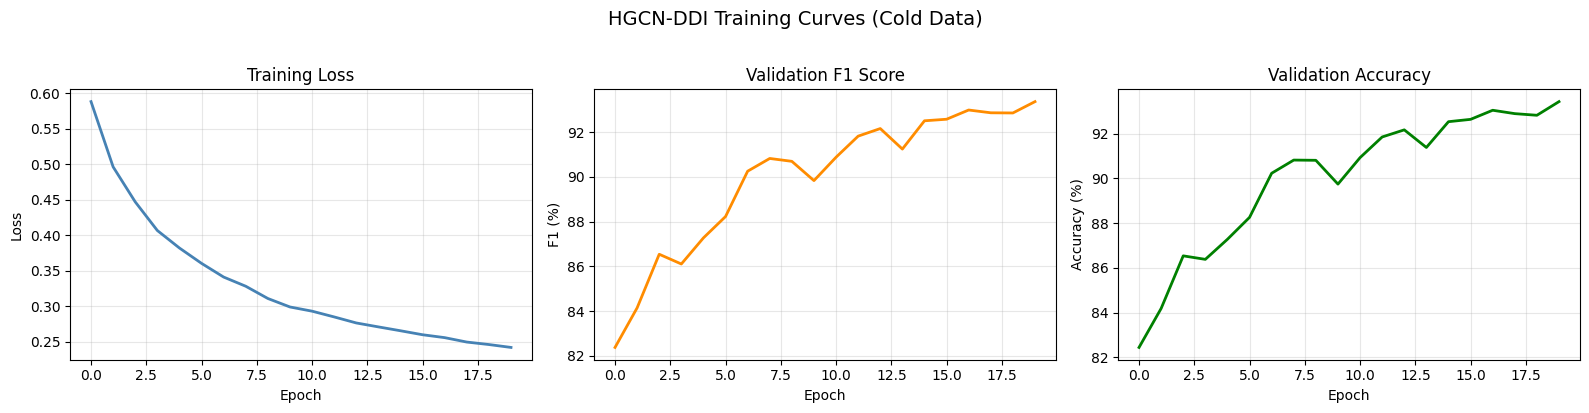

In [46]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curve
axes[0].plot(history['train_loss'], color='steelblue', lw=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Validation F1
axes[1].plot(history['val_f1'], color='darkorange', lw=2)
axes[1].set_title('Validation F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 (%)')
axes[1].grid(True, alpha=0.3)

# Validation Accuracy
axes[2].plot(history['val_acc'], color='green', lw=2)
axes[2].set_title('Validation Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy (%)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('HGCN-DDI Training Curves (Cold Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('hgnn_ddi_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrix


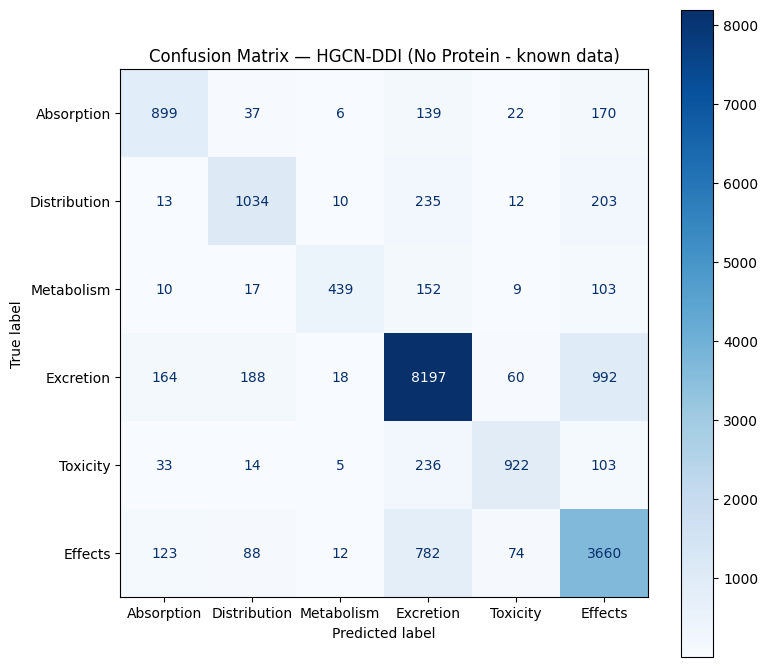


Per-class accuracy:
       Absorption : 70.6%  (1,273 samples)
     Distribution : 68.6%  (1,507 samples)
       Metabolism : 60.1%  (730 samples)
        Excretion : 85.2%  (9,619 samples)
         Toxicity : 70.2%  (1,313 samples)
          Effects : 77.2%  (4,739 samples)


In [49]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_true = [], []
loader = DataLoader(TensorDataset(test_src, test_dst, test_labels), batch_size=2048)

with torch.no_grad():
    for s, d, y in loader:
        logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
        all_preds.append(logits.argmax(1).cpu())
        all_true.append(y)

preds_np = torch.cat(all_preds).numpy()
true_np  = torch.cat(all_true).numpy()

cm = confusion_matrix(true_np, preds_np)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=class_names if USE_6_CLASSES else list(range(86))
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — HGCN-DDI (No Protein - known data)')
plt.tight_layout()
plt.savefig('hgnn_ddi_confusion_matrix.png', dpi=150)
plt.show()

# Print per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names if USE_6_CLASSES else range(86)):
    class_mask = true_np == i
    if class_mask.sum() > 0:
        acc = (preds_np[class_mask] == i).mean() * 100
        print(f'  {str(name):>15} : {acc:.1f}%  ({class_mask.sum():,} samples)')

#  🆕 Testing with unseen data
Cold-start on pairs

────────────────────────────────

Train drugs : {A, B, C, D, E}

Test pairs  : (A,F), (B,G) ...   ← one drug is new

Result      : Drops moderately, protein path helps



### Data Split

In [40]:
# ── Cold-start on pairs: test pairs where at least one drug is unseen ───
import numpy as np

all_drug_ids = list(drug2idx.keys())
np.random.seed(42)
np.random.shuffle(all_drug_ids)

# Hold out 20% of drugs completely from training
split_idx   = int(0.8 * len(all_drug_ids))
train_drugs = set(all_drug_ids[:split_idx])
test_drugs  = set(all_drug_ids[split_idx:])

print(f'Train drugs : {len(train_drugs):,}')
print(f'Held-out drugs : {len(test_drugs):,}')

all_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

# ── Three split types ──
# Warm : both drugs seen in training
# Semi : exactly one drug is unseen
# Cold : both drugs are unseen

def classify_pair(row):
    d1_unseen = row[id_col_1] in test_drugs
    d2_unseen = row[id_col_2] in test_drugs
    if not d1_unseen and not d2_unseen:
        return 'warm'
    elif d1_unseen and d2_unseen:
        return 'cold'
    else:
        return 'semi'

print('Classifying pairs...')
all_df['split_type'] = all_df.apply(classify_pair, axis=1)
print(all_df['split_type'].value_counts())

Train drugs : 1,364
Held-out drugs : 342
Classifying pairs...
split_type
warm    125298
semi     59559
cold      6951
Name: count, dtype: int64


In [41]:
# ── New training set: only warm pairs ─────
cold_train_df = all_df[all_df['split_type'] == 'warm'].reset_index(drop=True)
cold_test_warm_df = all_df[all_df['split_type'] == 'warm'].sample(frac=0.2, random_state=42)
cold_test_semi_df = all_df[all_df['split_type'] == 'semi'].reset_index(drop=True)
cold_test_cold_df = all_df[all_df['split_type'] == 'cold'].reset_index(drop=True)

def df_to_edge_tensors(df):
    src    = torch.tensor([drug2idx[d] for d in df[id_col_1]], dtype=torch.long)
    dst    = torch.tensor([drug2idx[d] for d in df[id_col_2]], dtype=torch.long)
    labels = torch.tensor(df['Y_6class' if USE_6_CLASSES else 'Y'].values, dtype=torch.long)
    return src, dst, labels

cs_train_src, cs_train_dst, cs_train_labels = df_to_edge_tensors(cold_train_df)
cs_warm_src,  cs_warm_dst,  cs_warm_labels  = df_to_edge_tensors(cold_test_warm_df)
cs_semi_src,  cs_semi_dst,  cs_semi_labels  = df_to_edge_tensors(cold_test_semi_df)
cs_cold_src,  cs_cold_dst,  cs_cold_labels  = df_to_edge_tensors(cold_test_cold_df)

print(f'Cold-start train pairs : {len(cs_train_src):,}')
print(f'Test — warm pairs      : {len(cs_warm_src):,}')
print(f'Test — semi-cold pairs : {len(cs_semi_src):,}')
print(f'Test — cold pairs      : {len(cs_cold_src):,}')

Cold-start train pairs : 125,298
Test — warm pairs      : 25,060
Test — semi-cold pairs : 59,559
Test — cold pairs      : 6,951


### Model Retrain on newly split data

In [42]:

# Step 1: rebuild A_ddi using only warm training pairs
#         this overwrites the global A_ddi that encode() references
A_ddi = edge_to_adj(cs_train_src, cs_train_dst, N_DRUGS, N_DRUGS, DEVICE)
print(f'Cold-start A_ddi rebuilt — {cs_train_src.shape[0]:,} edges')

# Step 2: fresh instance of the same model class
cs_model = HGCN_DDI(
    in_drug  = drug_features.shape[1],
    in_prot  = protein_features.shape[1],
    hidden   = CONFIG['hidden_dim'],
    out      = CONFIG['out_dim'],
    n_classes= CONFIG['n_classes'],
    dropout  = CONFIG['dropout'],
).to(DEVICE)

cs_optimizer = torch.optim.Adam(
    cs_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
cs_criterion = nn.CrossEntropyLoss()

# Step 3: training loop — identical to original
cs_train_dataset = TensorDataset(cs_train_src, cs_train_dst, cs_train_labels)
cs_train_loader  = DataLoader(cs_train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)

best_cs_f1    = 0
best_cs_state = None

print(f'\nTraining on cold-start split for {CONFIG["epochs"]} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val F1 (warm)":>13}')
print('-' * 38)

for epoch in range(1, CONFIG['epochs'] + 1):
    cs_model.train()
    total_loss = 0
    for s, d, y in cs_train_loader:
        s, d, y = s.to(DEVICE), d.to(DEVICE), y.to(DEVICE)
        cs_optimizer.zero_grad()
        logits = cs_model(drug_feats_dev, prot_feats_dev, s, d)
        loss   = cs_criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cs_model.parameters(), 1.0)
        cs_optimizer.step()
        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(cs_train_dataset)
    val_m    = evaluate(cs_model, cs_warm_src, cs_warm_dst, cs_warm_labels)
    print(f'{epoch:>6} | {avg_loss:>10.4f} | {val_m["f1"]:>12.2f}%')

    if val_m['f1'] > best_cs_f1:
        best_cs_f1    = val_m['f1']
        best_cs_state = {k: v.cpu().clone() for k, v in cs_model.state_dict().items()}

print(f'\n✅ Best warm-pair val F1: {best_cs_f1:.2f}%')

Cold-start A_ddi rebuilt — 125,298 edges

Training on cold-start split for 20 epochs...

 Epoch | Train Loss | Val F1 (warm)
--------------------------------------
     1 |     0.9840 |        72.19%
     2 |     0.5890 |        83.45%
     3 |     0.4857 |        82.90%
     4 |     0.4318 |        87.34%
     5 |     0.3982 |        88.99%
     6 |     0.3690 |        88.58%
     7 |     0.3507 |        87.97%
     8 |     0.3348 |        90.24%
     9 |     0.3176 |        91.34%
    10 |     0.3078 |        92.17%
    11 |     0.2974 |        91.63%
    12 |     0.2882 |        92.04%
    13 |     0.2791 |        92.18%
    14 |     0.2705 |        92.33%
    15 |     0.2638 |        93.15%
    16 |     0.2599 |        93.17%
    17 |     0.2554 |        93.25%
    18 |     0.2486 |        93.43%
    19 |     0.2450 |        94.18%
    20 |     0.2390 |        93.94%

✅ Best warm-pair val F1: 94.18%


### Evaluation on Warm, Semi & Cold Data


_______________________________

Warm pairs — both drugs seen

Semi-cold pairs — one drug seen, one unseen

Cold pairs — both drugs unseen

In [45]:
# ── Load best model and evaluate all three test sets ──────────────────────────
cs_model.load_state_dict({k: v.to(DEVICE) for k, v in best_cs_state.items()})

def evaluate_cs(src, dst, labels):
    if len(src) == 0:
        return {'f1': 0, 'accuracy': 0, 'precision': 0, 'recall': 0}
    return evaluate(cs_model, src, dst, labels)

warm_metrics = evaluate_cs(cs_warm_src,  cs_warm_dst,  cs_warm_labels)
semi_metrics = evaluate_cs(cs_semi_src,  cs_semi_dst,  cs_semi_labels)
cold_metrics = evaluate_cs(cs_cold_src,  cs_cold_dst,  cs_cold_labels)

# Original warm-start model results for comparison
orig_metrics = evaluate(model, test_src, test_dst, test_labels)

print('=' * 62)
print(f'{"Evaluation":>25} | {"F1":>8} | {"Accuracy":>9} | {"Recall":>8}')
print('=' * 62)
print(f'{"Original (warm-start)":>25} | {orig_metrics["f1"]:>7.2f}% | {orig_metrics["accuracy"]:>8.2f}% | {orig_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — warm pairs":>25} | {warm_metrics["f1"]:>7.2f}% | {warm_metrics["accuracy"]:>8.2f}% | {warm_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — semi pairs":>25} | {semi_metrics["f1"]:>7.2f}% | {semi_metrics["accuracy"]:>8.2f}% | {semi_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — cold pairs":>25} | {cold_metrics["f1"]:>7.2f}% | {cold_metrics["accuracy"]:>8.2f}% | {cold_metrics["recall"]:>7.2f}%')
print('=' * 62)

print('\nExpected pattern:')
print('  "warm" is better than "semi" which is better than "cold"')
print('  The gap between warm and cold shows how much')
print('  real protein embeddings (ESM-1b) would help.')

               Evaluation |       F1 |  Accuracy |   Recall
    Original (warm-start) |   78.95% |    78.99% |   78.99%
  Cold-split — warm pairs |   94.18% |    94.18% |   94.18%
  Cold-split — semi pairs |   56.40% |    57.91% |   57.91%
  Cold-split — cold pairs |   37.30% |    39.48% |   39.48%

Expected pattern:
  "warm" is better than "semi" which is better than "cold"
  The gap between warm and cold shows how much
  real protein embeddings (ESM-1b) would help.


### Visualization for Warm, Semi & Cold Data


In [51]:
# ── Reusable confusion matrix + per-class accuracy function ───────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['Absorption', 'Distribution', 'Metabolism',
               'Excretion',  'Toxicity',     'Effects']

def plot_confusion_and_accuracy(model, src, dst, labels, title, save_name):
    """
    Works for any model and any test split.
    Just pass in the model, edge tensors, labels, and a title.
    """
    if len(src) == 0:
        print(f'Skipping {title} — no samples.')
        return

    # ── Get predictions ────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_true = [], []
    loader = DataLoader(TensorDataset(src, dst, labels), batch_size=2048, shuffle=False)
    with torch.no_grad():
        for s, d, y in loader:
            logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
            all_preds.append(logits.argmax(1).cpu())
            all_true.append(y)

    preds_np = torch.cat(all_preds).numpy()
    true_np  = torch.cat(all_true).numpy()

    # ── Overall metrics ────────────────────────────────────────────────────────
    overall_f1  = f1_score(true_np, preds_np, average='weighted', zero_division=0) * 100
    overall_acc = accuracy_score(true_np, preds_np) * 100

    # ── Confusion matrix plot ──────────────────────────────────────────────────
    cm = confusion_matrix(true_np, preds_np)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=class_names if USE_6_CLASSES else list(range(86))
    )
    disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix\n{title}')

    # ── Per-class accuracy bar chart ───────────────────────────────────────────
    per_class_acc = []
    per_class_n   = []
    for i in range(len(class_names) if USE_6_CLASSES else 86):
        mask = true_np == i
        n    = mask.sum()
        acc  = (preds_np[mask] == i).mean() * 100 if n > 0 else 0
        per_class_acc.append(acc)
        per_class_n.append(n)

    display_names = class_names if USE_6_CLASSES else [str(i) for i in range(86)]
    bars = axes[1].bar(display_names, per_class_acc, color='steelblue', alpha=0.8)
    axes[1].set_ylim(0, 110)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'Per-Class Accuracy\n{title}')
    axes[1].axhline(y=overall_acc, color='red', linestyle='--',
                    linewidth=1.5, label=f'Overall: {overall_acc:.1f}%')
    axes[1].legend()

    # Add sample count labels on top of each bar
    for bar, acc, n in zip(bars, per_class_acc, per_class_n):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{acc:.1f}%\n(n={n:,})',
            ha='center', va='bottom', fontsize=8
        )

    plt.suptitle(f'Overall F1: {overall_f1:.2f}%  |  Overall Acc: {overall_acc:.2f}%',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f'\n{"─"*50}')
    print(f'  {title}')
    print(f'{"─"*50}')
    print(f'  Overall F1       : {overall_f1:.2f}%')
    print(f'  Overall Accuracy : {overall_acc:.2f}%')
    print(f'{"─"*50}')
    print(f'  {"Class":>15} | {"Accuracy":>9} | {"Samples":>8}')
    print(f'  {"─"*38}')
    for name, acc, n in zip(display_names, per_class_acc, per_class_n):
        flag = ' ⚠️' if acc < 70 else ''
        print(f'  {name:>15} | {acc:>8.1f}% | {n:>8,}{flag}')
    print(f'{"─"*50}\n')

print('plot_confusion_and_accuracy() ready')

plot_confusion_and_accuracy() ready


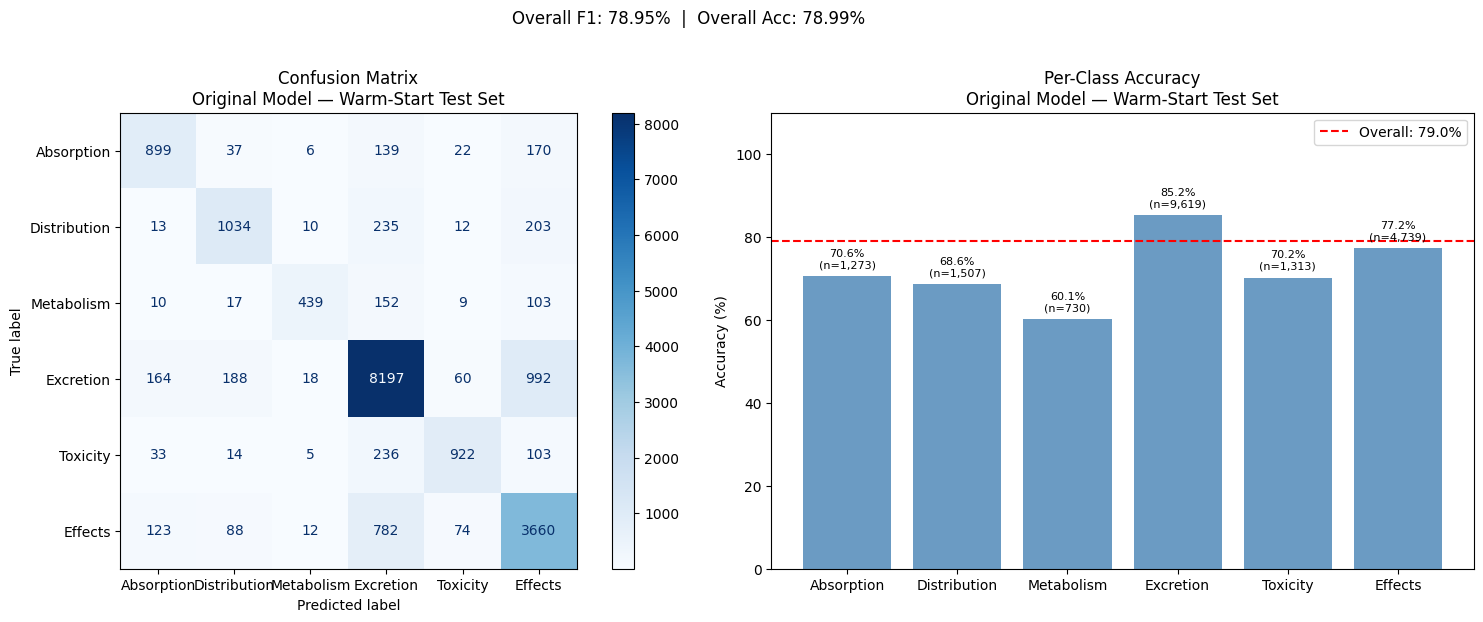


──────────────────────────────────────────────────
  Original Model — Warm-Start Test Set
──────────────────────────────────────────────────
  Overall F1       : 78.95%
  Overall Accuracy : 78.99%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     70.6% |    1,273
     Distribution |     68.6% |    1,507 ⚠️
       Metabolism |     60.1% |      730 ⚠️
        Excretion |     85.2% |    9,619
         Toxicity |     70.2% |    1,313
          Effects |     77.2% |    4,739
──────────────────────────────────────────────────



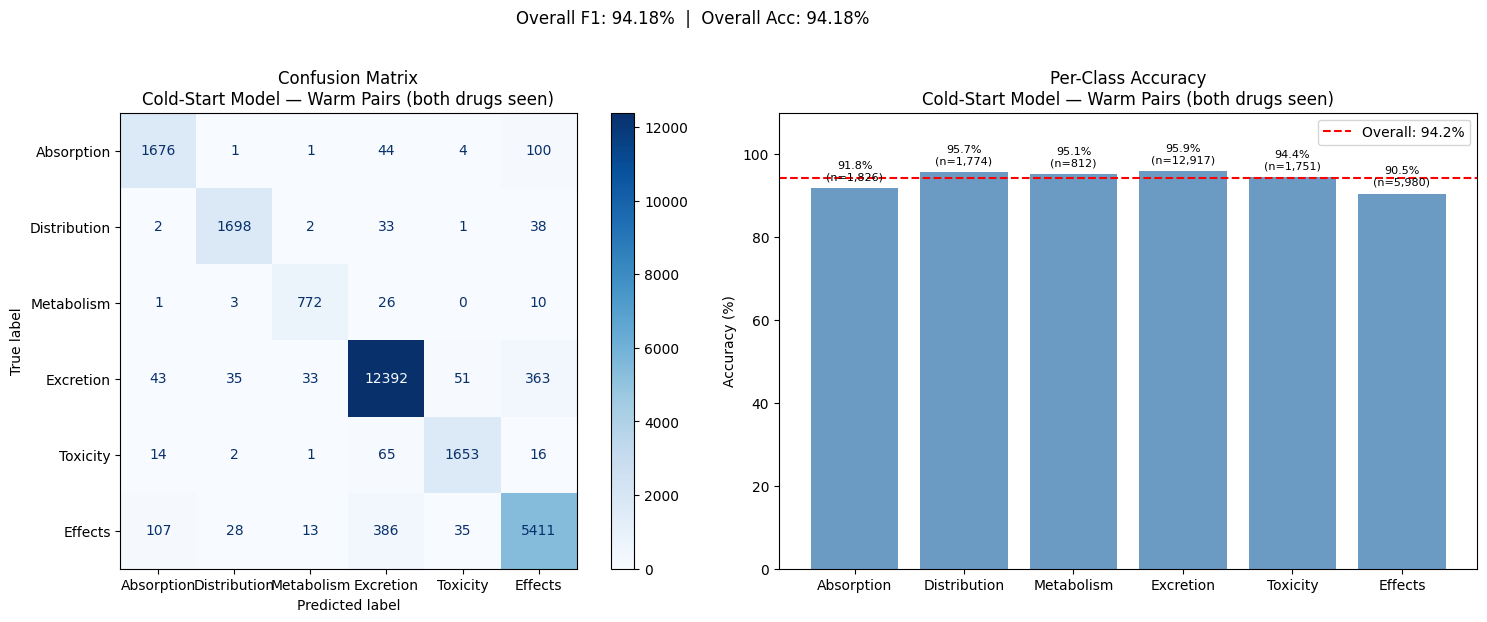


──────────────────────────────────────────────────
  Cold-Start Model — Warm Pairs (both drugs seen)
──────────────────────────────────────────────────
  Overall F1       : 94.18%
  Overall Accuracy : 94.18%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     91.8% |    1,826
     Distribution |     95.7% |    1,774
       Metabolism |     95.1% |      812
        Excretion |     95.9% |   12,917
         Toxicity |     94.4% |    1,751
          Effects |     90.5% |    5,980
──────────────────────────────────────────────────



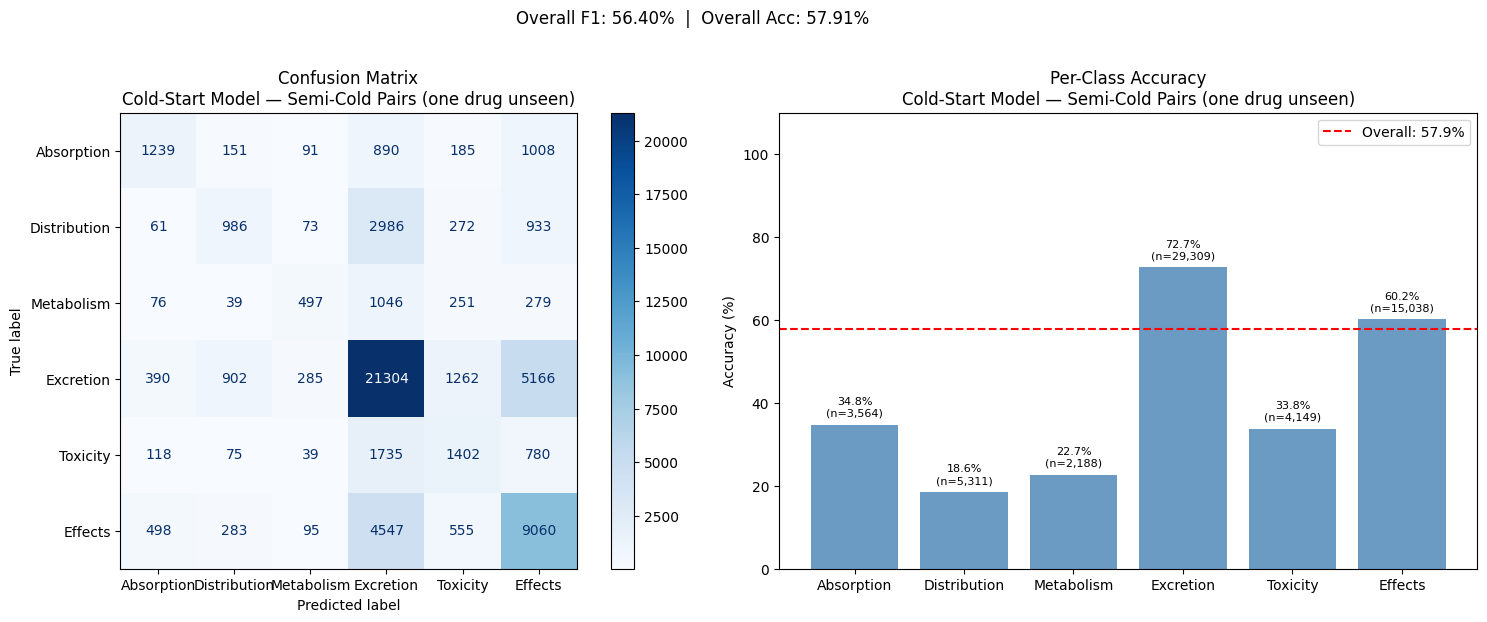


──────────────────────────────────────────────────
  Cold-Start Model — Semi-Cold Pairs (one drug unseen)
──────────────────────────────────────────────────
  Overall F1       : 56.40%
  Overall Accuracy : 57.91%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     34.8% |    3,564 ⚠️
     Distribution |     18.6% |    5,311 ⚠️
       Metabolism |     22.7% |    2,188 ⚠️
        Excretion |     72.7% |   29,309
         Toxicity |     33.8% |    4,149 ⚠️
          Effects |     60.2% |   15,038 ⚠️
──────────────────────────────────────────────────



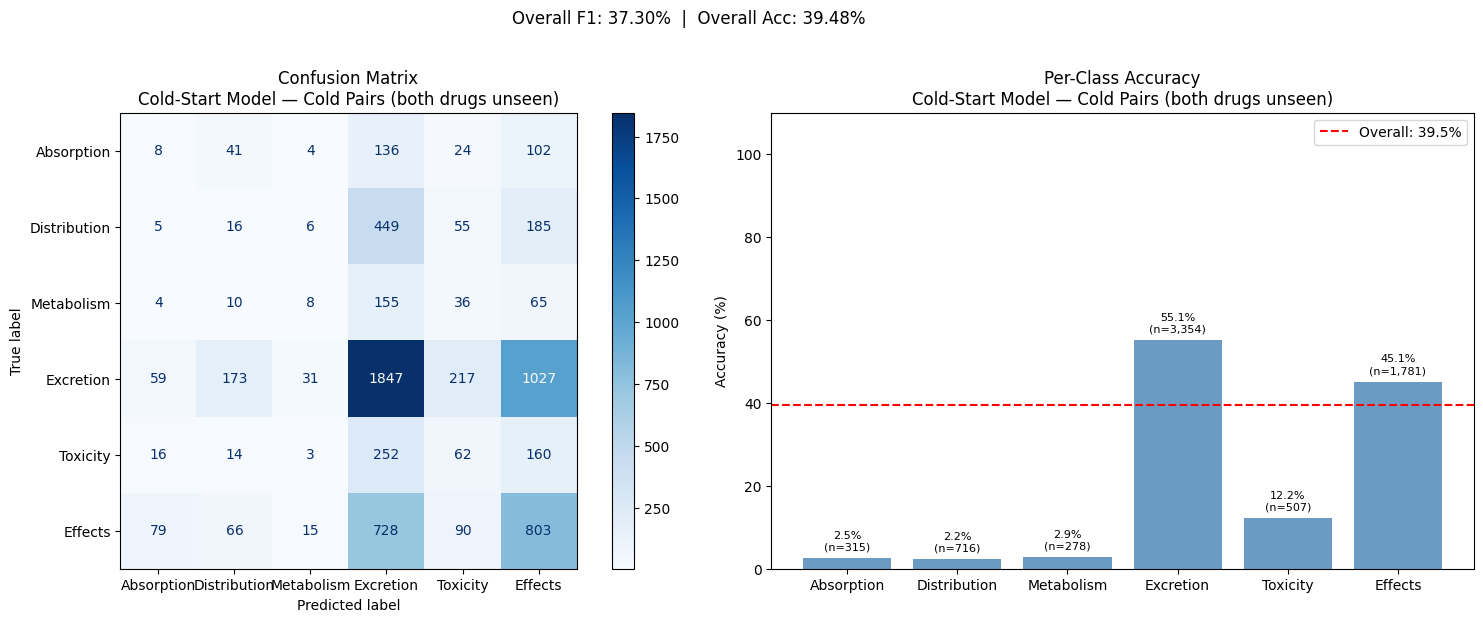


──────────────────────────────────────────────────
  Cold-Start Model — Cold Pairs (both drugs unseen)
──────────────────────────────────────────────────
  Overall F1       : 37.30%
  Overall Accuracy : 39.48%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |      2.5% |      315 ⚠️
     Distribution |      2.2% |      716 ⚠️
       Metabolism |      2.9% |      278 ⚠️
        Excretion |     55.1% |    3,354 ⚠️
         Toxicity |     12.2% |      507 ⚠️
          Effects |     45.1% |    1,781 ⚠️
──────────────────────────────────────────────────



In [52]:
# ── Load best cold-start model ─────────────────────────────────────────────────
cs_model.load_state_dict({k: v.to(DEVICE) for k, v in best_cs_state.items()})

# ── Original model on original test set ───────────────────────────────────────
plot_confusion_and_accuracy(
    model,
    test_src, test_dst, test_labels,
    title     = 'Original Model — Warm-Start Test Set',
    save_name = 'cm_original.png'
)

# ── Cold-start model on warm pairs ────────────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_warm_src, cs_warm_dst, cs_warm_labels,
    title     = 'Cold-Start Model — Warm Pairs (both drugs seen)',
    save_name = 'cm_cold_warm.png'
)

# ── Cold-start model on semi-cold pairs ───────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_semi_src, cs_semi_dst, cs_semi_labels,
    title     = 'Cold-Start Model — Semi-Cold Pairs (one drug unseen)',
    save_name = 'cm_cold_semi.png'
)

# ── Cold-start model on cold pairs ────────────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_cold_src, cs_cold_dst, cs_cold_labels,
    title     = 'Cold-Start Model — Cold Pairs (both drugs unseen)',
    save_name = 'cm_cold_cold.png'
)

## 💾 Save & Load Model

In [39]:
# Save
torch.save({
    'model_state_dict': best_model_state,
    'config'          : CONFIG,
    'drug2idx'        : drug2idx,
    'test_metrics'    : test_metrics,
}, 'hgcn_ddi_checkpoint.pt')
print('✅ Model saved to hgcn_ddi_no_prot.pt')

# Load model
# checkpoint = torch.load('hgcn_ddi_checkpoint.pt')
# model.load_state_dict({k: v.to(DEVICE) for k, v in checkpoint['model_state_dict'].items()})

✅ Model saved to hgcn_ddi_no_prot.pt


---
## 📝 Notes & Tips for Full Reproduction

| Aspect | This Notebook | Full Paper Reproduction |
|---|---|---|
| Protein features | Random placeholders | Load PrimeKG + run ESM-1b |
| DPI/PPI edges | Random stubs | Extract from PrimeKG |
| 6-class mapping | Approximate buckets | Use official DrugBank category labels |
| Negative samples | Not included | Add 10% random negative edges at test time |
| Training time | ~10 min (T4) | ~1-2 hours with ESM-1b |

### Loading Real PrimeKG Data
```python
# Download PrimeKG
import urllib.request
urllib.request.urlretrieve(
    'https://dataverse.harvard.edu/api/access/datafile/6180616',
    'kg.csv'
)
kg_df = pd.read_csv('kg.csv')
dpi_df = kg_df[kg_df['relation'] == 'drug_protein']
ppi_df = kg_df[kg_df['relation'] == 'protein_protein']
```

### Switching to HGAT-DDI
Replace `dglnn.GraphConv` with `dglnn.GATConv` in the `HeteroGraphConv` dict and add `num_heads=4`.